# 01 · Exploratory Data Analysis — Raw Data

**UC Berkeley Capstone — Predicting YouTube engagement relative to a channel's own baseline**

## Business understanding

For an individual creator, the first 24 hours after publishing a video are
decisive: if a video is not gaining traction early there is only a narrow window
to react (adjust the title or thumbnail, promote it, or re-upload). For a
platform, the same early signal informs recommendation seeding and creator
tooling.

**Research question.** *Can we predict whether a video will achieve
above-median engagement within 7 days of publication, using only signals
observable at upload time or within the first 24 hours?*

Engagement is defined as `(likes + comments) / views` at the 7-day mark,
benchmarked against **that channel's own historical median**. Because each video
is judged against its own channel, roughly 50% of any channel's videos land
above its median by construction — which makes the problem meaningful across
creators of any size and removes class imbalance from the outset.

## What this notebook covers

This notebook explores the **raw data volume** — the snapshot rows as collected,
and the cleaned per-video table that the modeling pipeline produces before any
feature engineering. It is re-run infrequently: the *nature* of the data does
not change between collection cycles, only its volume.

> **Sequence:** this is notebook 1 of 5. See [notebooks.md](./notebooks.md) for
> how the notebooks fit together.

## Configuration & guardrails

Every notebook in this sequence carries a **`DRY_RUN`** guardrail (default
`True`). When `True`, no write operations occur — here that means EDA figures
are *not* saved to disk. `DRY_RUN` is passed into `VersionConfig.dry_run(...)`
so the same switch governs every write across the sequence; the snapshotter
stages and `commit()` honor it centrally rather than each cell branching on it.

This notebook loads from the most recent **committed** GCS data snapshot (no
BigQuery call) and runs only the two stages needed to produce the raw per-video
table: `DataLoader` → `DataPreprocessor`.

In [1]:
import sys
import os

# Make the capstone package importable (notebook lives in notebooks/, code in src/capstone/).
sys.path.append(os.path.abspath("../"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pipeline.version_config import VersionConfig
from pipeline.pipeline_run import PipelineRun
from pipeline.factory import PipelineFactory
from pipeline.stages import eda

IMAGES_FOLDER = "../../../images/eda/"

# DRY_RUN = True  -> no figures written to disk (safe default for review runs).
# DRY_RUN = False -> figures saved under IMAGES_FOLDER.
DRY_RUN = True

# DRY_RUN doubles as the figure-write guard: in a dry run we pass save_figure_name=None
# so no image files are written to disk; flip DRY_RUN to False to persist figures.
def fig_path(name):
    return None if DRY_RUN else f"{IMAGES_FOLDER}{name}"

config = VersionConfig.load().dry_run(DRY_RUN).build()
run = PipelineRun(config)
stages = PipelineFactory.retrain_existing_data(config)

VersionConfig loaded:
  data:          v3.4 (raw_suffix='real')
  baselines:     v4.0
  model:         v5.3
  hyperparams:   v1.1
  use_synthetic: False

VersionConfig ready:
  Active flags      : ['none (dry run)']
  data              : v3.4 (unchanged)
  baselines         : v4.0 (unchanged)
  model             : v5.3 (unchanged)
  hyperparams       : v1.1 (unchanged)
  raw_version       : v3.4_real
  next_final_version: v3.4_100real
  model_version     : v5.3
  baselines_version : v4.0
  hyperparam_version: v1.1
  use_synthetic     : False
  dry_run           : True  (no GCS writes will occur)

  DRY RUN — set .dry_run(False) to persist artifacts and commit versions.


### Pipeline execution

`DataLoader` reads the parquet snapshot pinned in `config/versions.json`;
`DataPreprocessor` pivots the long-format poll rows into one wide row per video,
joins the per-channel baseline medians, and runs structural cleanup. We stop
here — no splitting, scaling, or modeling happens in this notebook.

In [2]:
stages.loader.run(run)
stages.preprocessor.run(run)
run.summary()

Loaded snapshot 'v3.4_real': 60696 rows from 2026-04-29
  Polls: {'upload': 21398, '24h': 20906, '7d': 18392}
Loaded baselines 'v4.0': 28814 baseline videos, 974 median rows (974 channels)
Building clean dataset
snapshot cols: Index(['video_id', 'poll_timestamp', 'channel_id', 'channel_handle', 'title',
       'view_count', 'like_count', 'comment_count', 'face_count', 'brightness',
       'colorfulness', 'vertical', 'tier', 'description', 'tags',
       'duration_seconds', 'category_id', 'category_name', 'published_at',
       'poll_label', 'hours_since_publish', 'subscriber_count',
       'contains_synthetic_media'],
      dtype='object')

[1/3] Pivoting snapshots...
  Videos with all 3 polls: 18334 (dropped 3111 incomplete)
  Pivoted shape: (18403, 34)

[2/3] Joining baseline medians...
  Baseline join: 18403/18403 videos matched a channel median

[3/3] Cleaning data...
  Dropped 15 row(s) with null contains_synthetic_media (private/failed harvest).
  Cleaned: 18388 rows × 40 columns

## Part 1 — Raw collection volume

The harvester records up to three labeled snapshots per video — `upload`
(within ~6h of publishing), `24h`, and `7d` — stored as separate rows in
long format (`run.df_videos`). Only videos with a **complete triplet** can be
modeled, because the growth-rate features require all three time points. The
cells below quantify the raw collection volume and how much survives the
complete-triplet requirement.

In [3]:
videos = run.df_videos
print(f"Raw snapshot rows:      {len(videos):,}")
print(f"Distinct videos:        {videos['video_id'].nunique():,}")
print(f"Distinct channels:      {videos['channel_id'].nunique():,}")
print(f"Collection window:      {videos['poll_timestamp'].min()}  ->  {videos['poll_timestamp'].max()}")
print("\nRows per poll label:")
print(videos["poll_label"].value_counts().to_string())

Raw snapshot rows:      60,696
Distinct videos:        21,445
Distinct channels:      846
Collection window:      2026-03-06 16:44:06.529262+00:00  ->  2026-04-29 19:05:17.033864+00:00

Rows per poll label:
poll_label
upload    21398
24h       20906
7d        18392


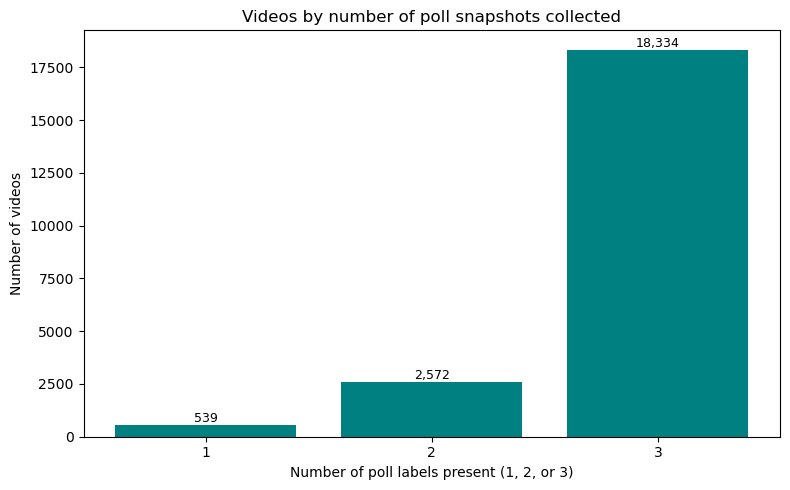

Complete triplets (modelable): 18,334 of 21,445 videos (85.5%)


In [4]:
# How many videos have all three poll labels (the modelable "complete triplets")?
polls_per_video = videos.groupby("video_id")["poll_label"].nunique()
triplet_counts = polls_per_video.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(triplet_counts.index.astype(str), triplet_counts.values, color="teal")
ax.set_title("Videos by number of poll snapshots collected")
ax.set_xlabel("Number of poll labels present (1, 2, or 3)")
ax.set_ylabel("Number of videos")
for x, y in zip(triplet_counts.index.astype(str), triplet_counts.values):
    ax.text(x, y, f"{y:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
if not DRY_RUN:
    plt.savefig(f"{IMAGES_FOLDER}00_poll_completeness.png")
plt.show()

complete = int((polls_per_video == 3).sum())
print(f"Complete triplets (modelable): {complete:,} of {videos['video_id'].nunique():,} videos "
      f"({complete / videos['video_id'].nunique():.1%})")

## Part 2 — Cleaned per-video table (`df_clean`)

`df_clean` is the output of `DataPreprocessor`: one wide row per complete-triplet
video, with raw engagement counts at each snapshot, the joined channel baseline
medians, and categorical metadata (`vertical`, `tier`). This is the table all
feature engineering builds on.

In [5]:
eda.set_active_df(run, run.df_clean)

df = run.active_eda_df
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nDtype breakdown:")
print(df.dtypes.value_counts().to_string())
df.describe()

Shape: 18,388 rows x 40 columns

Dtype breakdown:
Int64                  18
object                 11
float64                 6
datetime64[us, UTC]     4
boolean                 1


,duration_seconds,face_count,brightness,colorfulness,view_count_upload,like_count_upload,comment_count_upload,subscriber_count_upload,hours_since_publish_upload,view_count_24h,...,view_count_7d,like_count_7d,comment_count_7d,subscriber_count_7d,hours_since_publish_7d,baseline_baseline_video_count,baseline_median_views,baseline_median_likes,baseline_median_comments,baseline_median_engagement_rate
count,18388.0,18388.0,18388.000000,18388.000000,18388.0,18388.0,18388.0,18388.0,18388.000000,18388.0,...,18388.0,18388.0,18388.0,18388.0,18388.000000,18388.0,18388.0,18388.0,18388.0,18388.000000
mean,965.064607,0.838862,77.215701,42.470127,6318.825538,367.412062,24.587938,1518987.213944,3.417893,44201.740809,...,112016.922939,2686.931858,113.112628,1522596.899065,156.192116,29.012127,62139.242223,2071.750979,80.75,0.037382
std,2611.282766,0.986159,28.786276,23.613631,35388.138906,1485.632962,100.310944,2359749.493382,51.988616,314526.114571,...,1154408.653465,13479.801973,454.763266,2365334.149307,7.562357,3.302931,235839.545552,7557.687624,225.98307,0.026633
min,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,1010.0,-0.020000,0.0,...,0.0,0.0,0.0,1020.0,0.890000,7.0,11.0,0.0,0.0,0.000000
25%,43.0,0.0,58.726069,24.999451,60.0,4.0,0.0,39600.0,0.960000,657.0,...,1122.0,25.0,1.0,39700.0,156.340000,30.0,1202.0,28.0,1.0,0.018735
50%,158.5,1.0,74.927222,37.235376,420.0,25.0,1.0,298000.0,2.050000,3017.0,...,5864.0,185.0,8.0,299000.0,157.080000,30.0,5980.0,186.0,7.0,0.030340
75%,972.0,1.0,93.033458,56.300295,1872.0,146.0,9.0,1830000.0,3.350000,13957.75,...,31137.0,976.25,50.25,1840000.0,158.070000,30.0,29230.0,871.0,47.0,0.051282
max,86134.0,14.0,214.873264,170.229322,1650228.0,52463.0,4587.0,10000000.0,4948.330000,26047103.0,...,105938940.0,650419.0,15102.0,10000000.0,275.000000,30.0,4589046.0,135730.0,5977.0,0.200666


### Data quality — missing values & duplicates

This project does **not** impute. Incomplete records are handled structurally at
the stage that introduces the gap:

- videos without all three poll labels are dropped during the pivot;
- videos whose channel has no baseline median are dropped at the join;
- videos whose `contains_synthetic_media` flag is null are dropped during
  cleanup — a null there means the platform flag could not be retrieved,
  typically because the video was later made private or failed mid-harvest.
  These are few, so they are excluded rather than imputed.

The cells below confirm `df_clean` carries no remaining nulls and that
`video_id` is effectively unique.

In [6]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
quality = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
quality = quality[quality["null_count"] > 0]

if quality.empty:
    print("No missing values detected in df_clean.")
else:
    print(f"Columns with nulls ({len(quality)}):")
    display(quality.sort_values("null_count", ascending=False))

n_dup = df.duplicated(subset="video_id").sum()
print(f"\nTotal rows: {len(df):,}  |  Unique video_ids: {df['video_id'].nunique():,}  |  Duplicate video_ids: {n_dup}")

No missing values detected in df_clean.

Total rows: 18,388  |  Unique video_ids: 18,319  |  Duplicate video_ids: 69


### Outlier analysis

Engagement metrics follow a power-law distribution: a few viral videos receive
orders of magnitude more views than the median. Standard IQR fences
(Q1 − 1.5·IQR, Q3 + 1.5·IQR) quantify how many rows fall outside the expected
range per feature.

**Decision: outliers are retained.** These are real observations, not data-entry
errors. Removing viral events would bias the dataset and distort the
channel-relative baseline that defines the target. The engineered ratio/growth
features compress extreme raw counts, and the tree models are robust to them. A
high `pct_outliers` on a raw count column is expected and is not a data-quality
problem.

In [7]:
exclude_ = {"video_id", "above_baseline", "is_short", "is_long"}
num_cols_ = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_]

rows_ = []
for col in num_cols_:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    rows_.append({
        "feature": col,
        "iqr": round(iqr, 3),
        "n_outliers": n_out,
        "pct_outliers": round(n_out / len(s) * 100, 2),
    })

pd.DataFrame(rows_).sort_values("pct_outliers", ascending=False).reset_index(drop=True)

,feature,iqr,n_outliers,pct_outliers
0,baseline_median_likes,843.000,3001,16.32
1,baseline_median_views,28028.000,2914,15.85
2,like_count_7d,951.250,2888,15.71
3,comment_count_upload,9.000,2878,15.65
4,comment_count_7d,49.250,2875,15.64
5,comment_count_24h,31.000,2847,15.48
6,view_count_7d,30015.000,2835,15.42
7,like_count_upload,142.000,2825,15.36
8,like_count_24h,564.000,2807,15.27
9,view_count_upload,1812.000,2803,15.24


### Engagement metric distributions

Plain histograms across all continuous features in `df_clean`. The right skew is
the expected power-law signature of raw engagement counts; the long right tail is
the retained viral outliers. (KDE is omitted from the full grid for speed — see
the next cell for smoothed curves on the priority features.)

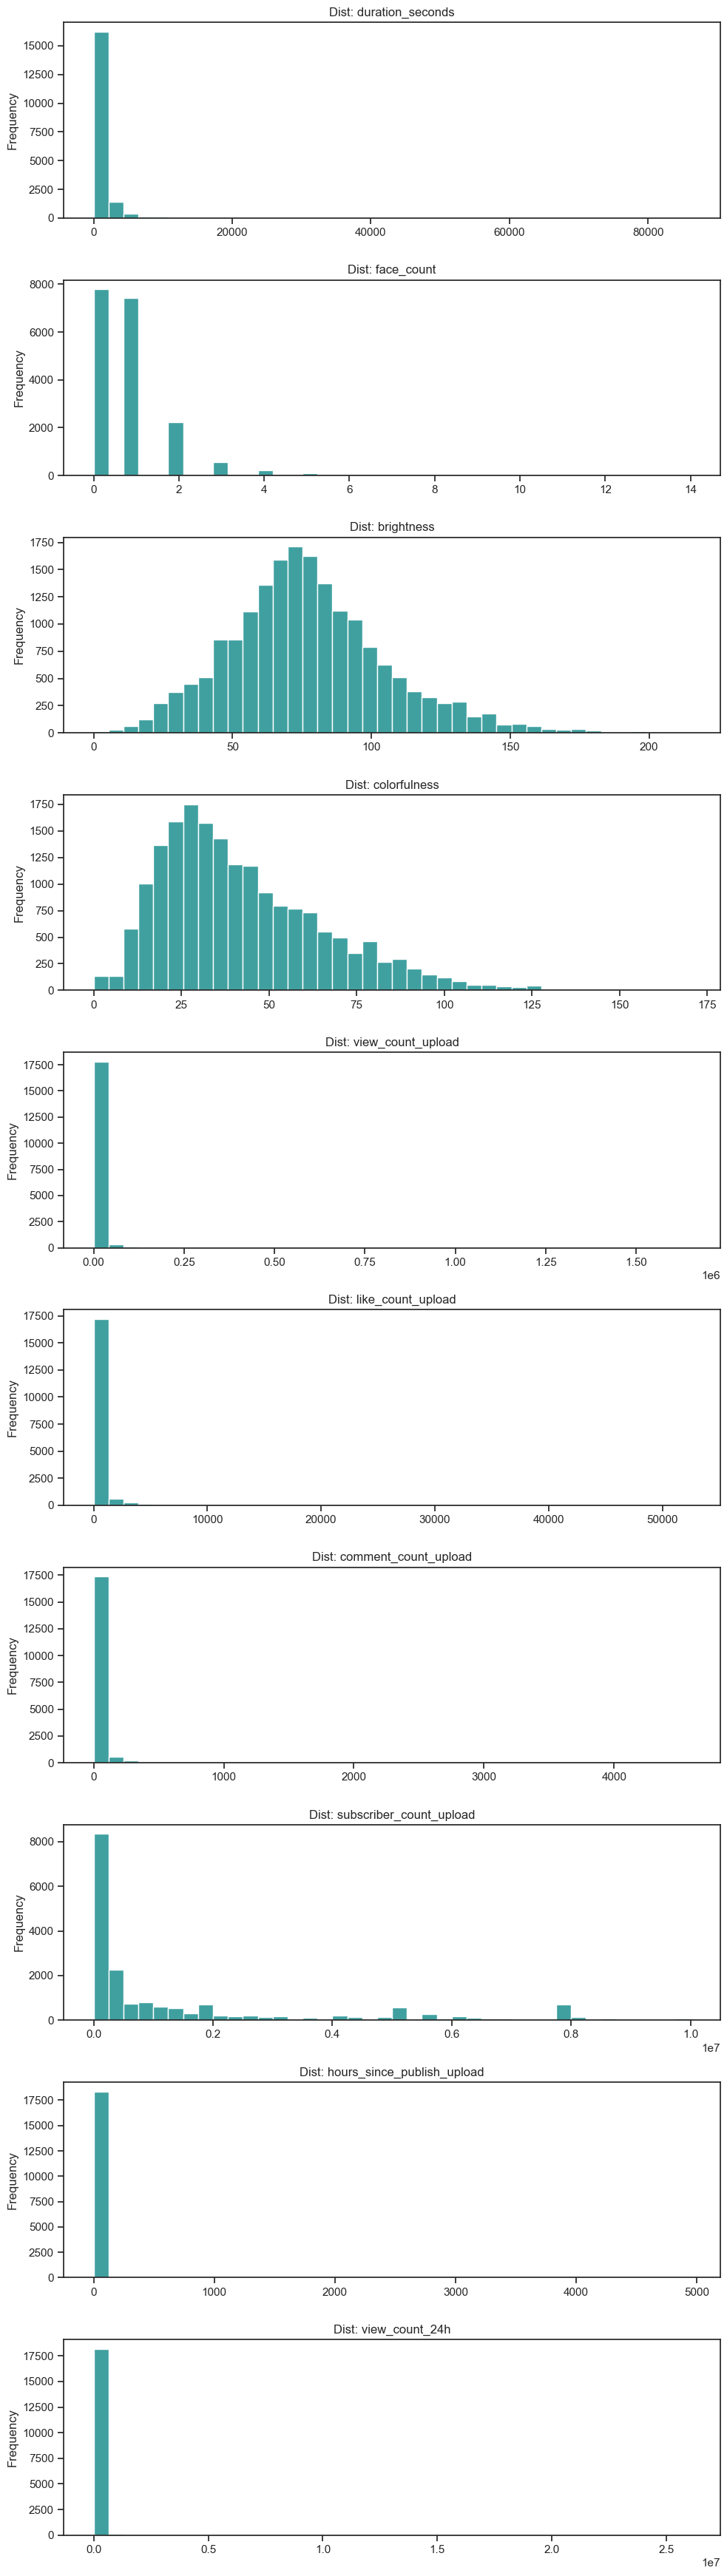

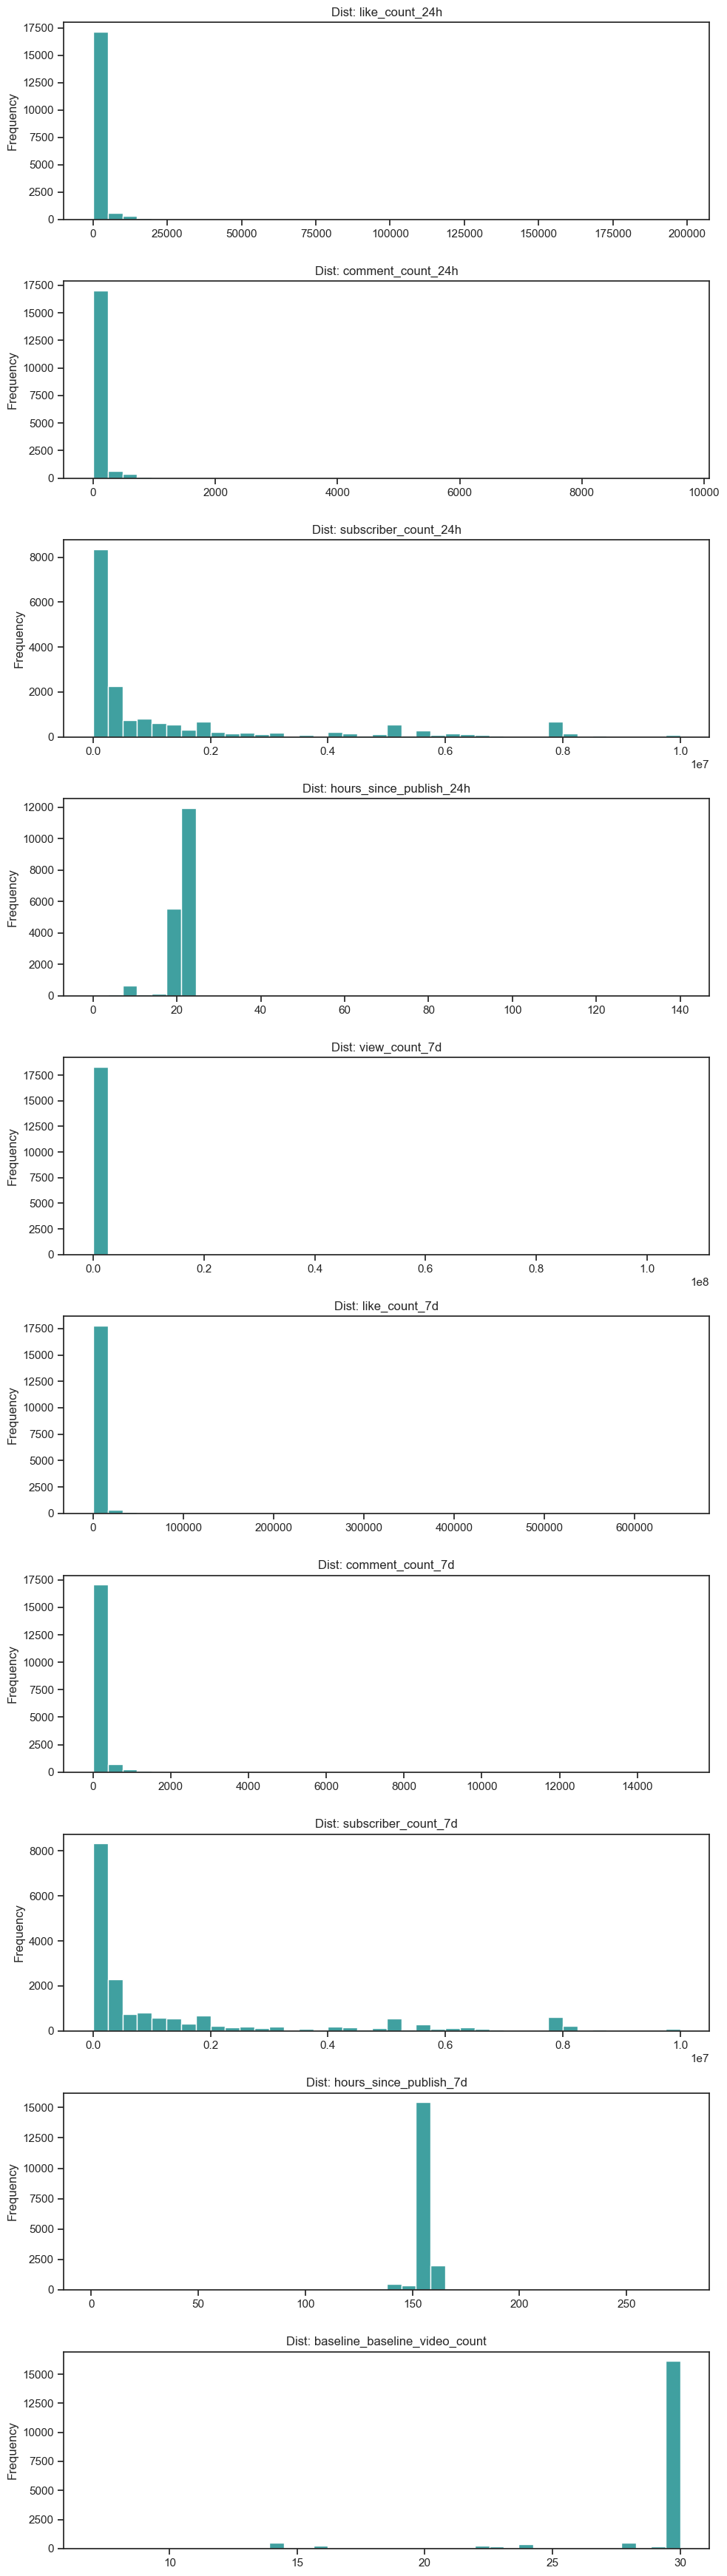

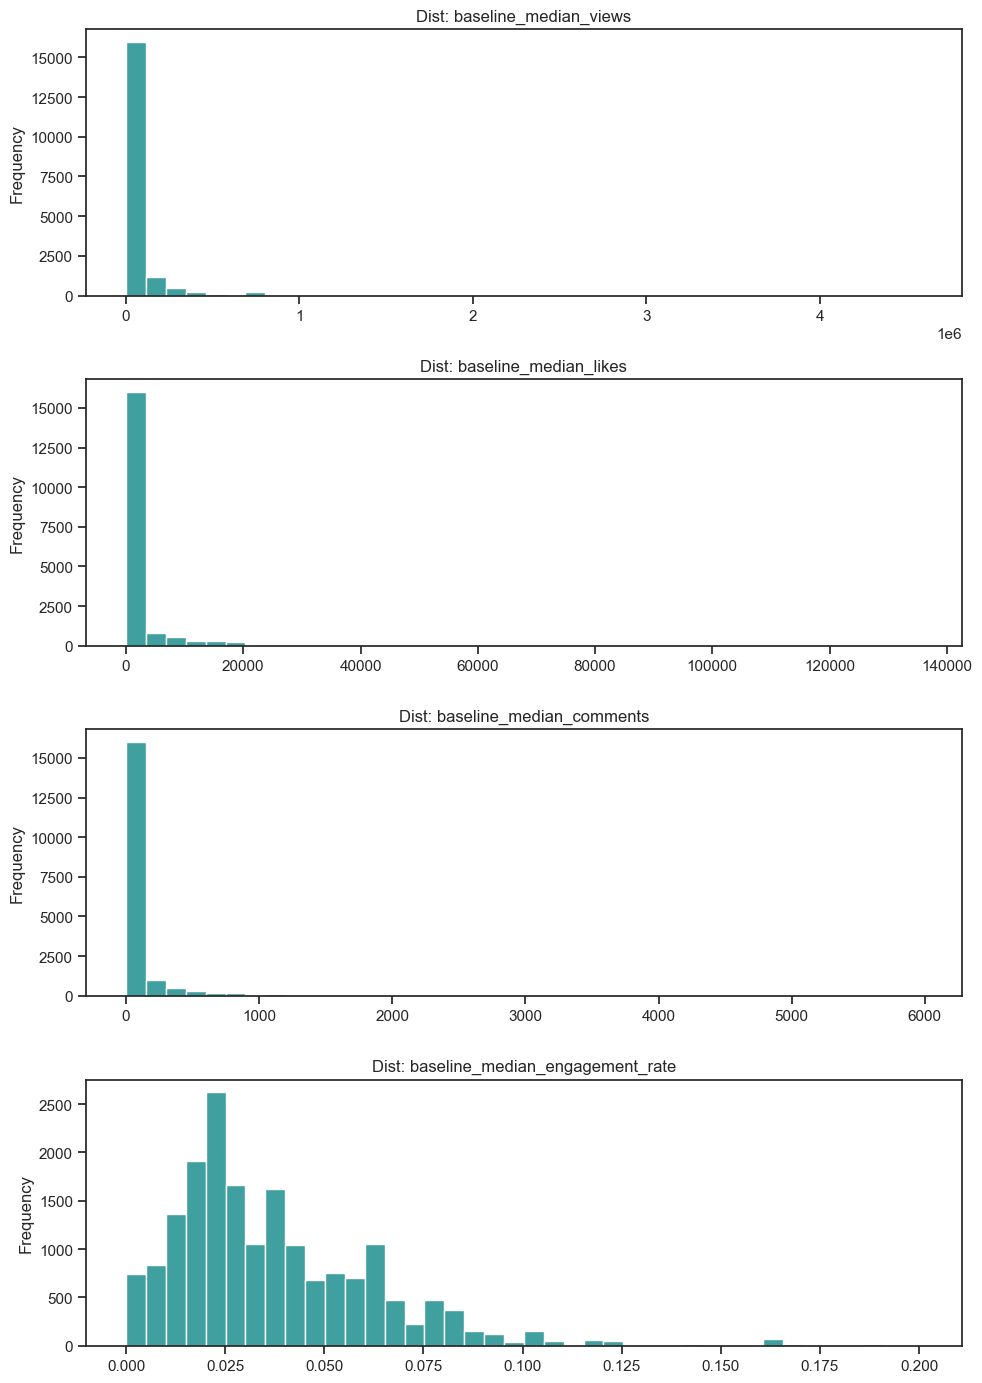

In [8]:
eda.plot_engagement_distribution(run, save_figure_name=fig_path("01_engagement_distributions.png"))

### Priority engagement signals — with KDE

Smoothed density curves for the core engagement signals (the three snapshot view
counts plus 24h likes/comments). These anchor the target definition and the
growth-rate features. KDE is computed on a fixed 200-point grid, so it stays fast
regardless of dataset size.

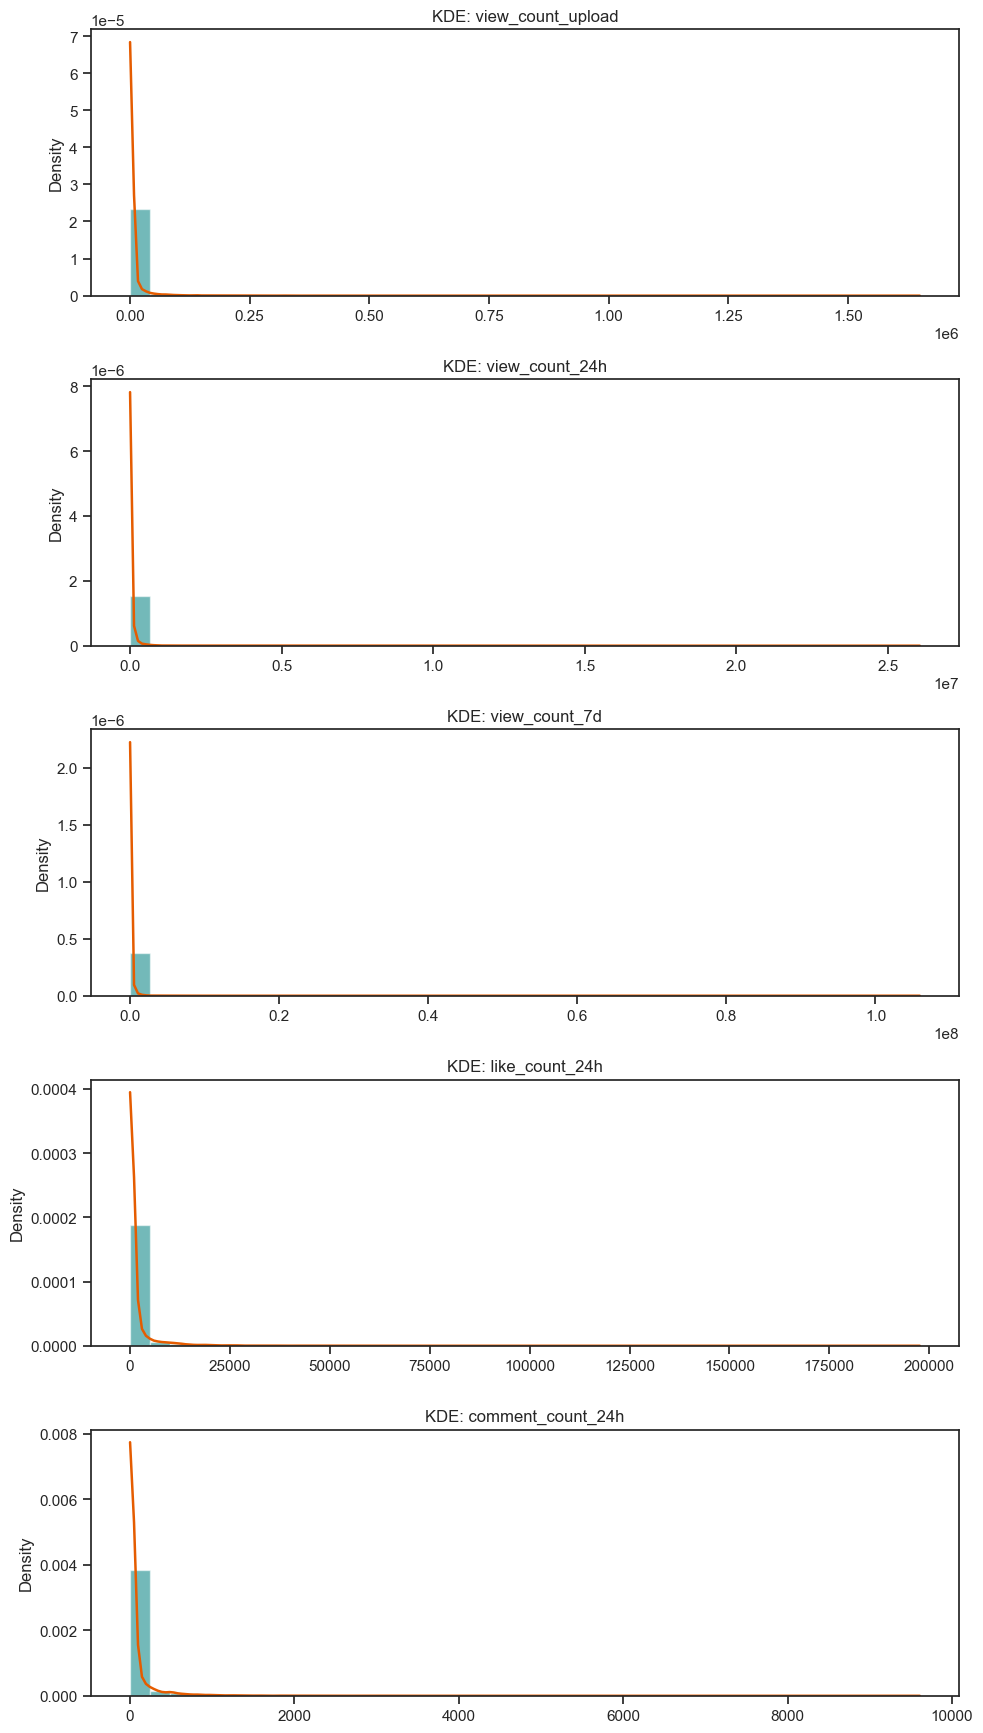

In [9]:
eda.plot_kde_distributions(run, save_figure_name=fig_path("02_engagement_kde_distributions.png"))

### Vertical segmentation — view velocity

Distribution of `view_count_24h` across content verticals. The boxplot shows
medians at very different scales per vertical — direct evidence that raw counts
are **not** comparable across content categories, which is exactly why the
pipeline normalizes against each channel's own baseline. The density overlay
exposes distributional shape differences the boxplot summary hides.

/Users/jelanigould-bailey/Desktop/uc_berkeley_capstone_repo/repo/src/capstone/pipeline/stages/eda.py:321: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="vertical", y=feature, palette="Set2", order=verticals_)


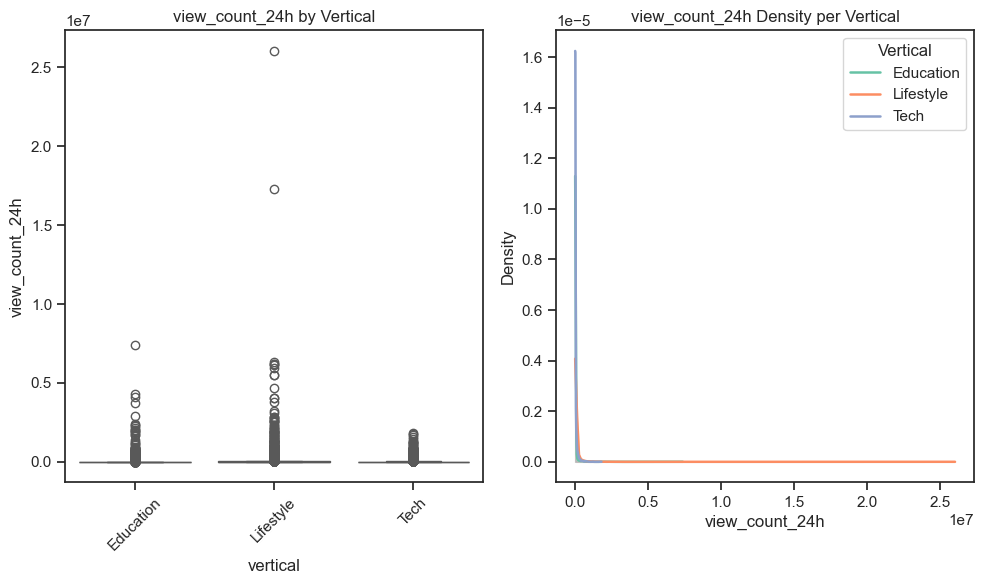

In [10]:
eda.plot_vertical_segmentation(run, feature="view_count_24h", save_figure_name=fig_path("03_view_velocity.png"))

## Findings — raw data

- The collection pipeline yields a large pool of snapshot rows, of which the
  **complete-triplet** subset (videos observed at upload, 24h, and 7d) is the
  modelable population. The drop from raw rows to triplets is expected and
  handled structurally, not by imputation.
- `df_clean` is clean by construction: no nulls and effectively unique
  `video_id`s. No imputation is required.
- Raw engagement metrics are heavily right-skewed (power-law) and not comparable
  across verticals — motivating both the **channel-relative target** and the
  **normalized/ratio features** introduced downstream.

**Next:** [02 · Feature engineering + engineered-data EDA](./02_feature_engineering_eda.ipynb).